In [162]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Optional
from scipy import stats
from datasets import (
    Dataset
)


In [173]:
def load_from_parquet(parquet_path: Path) -> pd.DataFrame:
    """Load a DataFrame from a Parquet file.

    Args:
        csv_path:
            Path to the CSV file.

    Returns:
        Loaded DataFrame.
    """
    return pd.read_parquet(parquet_path)


df = load_from_parquet(Path("../reports/metrics/combined_detailed_results_with_embeddings.parquet"))

# load dataset for evaluation
evaluation_dataset = Dataset.load_from_disk("../data/huggingface/datasets/test-sets/CoRal-project--coral-v2-read_aloud-test-unfiltered")

df.head()

,id,prediction,label,clip_length,CER,WER,model,dataset_name,dataset_subset,dataset_split,prediction_embedding,label_embedding,semantic_distance
0,rec_90dda503d68dc197f80219a7d3b129a9,derimod udøves retsplanen i det hele i det tid...,derimod udøvedes retsplejen i det hele i det t...,10.26,0.104167,0.266667,whisper-large-v3,coral-v2,read_aloud,test,"[-0.014361421, 0.05218921, -0.018706942, -0.09...","[-0.03685369, 0.03144104, -0.037021983, -0.117...",0.166795
1,rec_becc6eb53b441b31116584cd5c4e1c51,bauer klønge støtter kløngeorganisationer til ...,begge klynger støttes af klyngeorganisationer ...,7.32,0.234568,0.727273,whisper-large-v3,coral-v2,read_aloud,test,"[-0.07104228, -0.12548853, -0.06338177, -0.015...","[-0.0125311585, -0.060128797, -0.007917432, -0...",0.517030
2,rec_e59f62c2675fea5f9e7e726b51283250,i mildere tilfælde kan asmalt klare sig med pa...,i mildere tilfælde kan smerterne klares med pa...,8.10,0.147059,0.300000,whisper-large-v3,coral-v2,read_aloud,test,"[0.019092456, -0.023992827, -0.031023178, 0.02...","[0.03683996, -0.028660791, 0.04380101, 0.11237...",0.347441
3,rec_a47501841f128c1e6eb7fdd21647aa14,grønt er et ørelov liges her gennem og umanget...,grant at ødelægge lees hær gennem udmattelse v...,9.96,0.376344,0.857143,whisper-large-v3,coral-v2,read_aloud,test,"[0.028158227, -0.008324441, 0.06434102, -0.056...","[-0.04051919, 0.16661945, 0.01602321, -0.03350...",0.748699
4,rec_9a4da4e1a39901165014ad7354ac8e4f,der er lavet scenarier der forsøger at vise hv...,der er lavet scenarier der søger at vise hvord...,5.82,0.038462,0.071429,whisper-large-v3,coral-v2,read_aloud,test,"[-0.12290491, -0.02050186, 0.007368673, -0.010...","[-0.11009042, -0.02908404, 0.0042077433, -0.00...",0.019895


In [168]:
evaluation_dataset[0]

{'id_recording': 'rec_90dda503d68dc197f80219a7d3b129a9',
 'id_sentence': 'sen_00008696',
 'id_speaker': 'spe_de430b1197cf26cb5f4011656a728ee5',
 'text': 'derimod udøvedes retsplejen i det hele i det tidligere omfang af rigsretten og landenes domstole',
 'location': 'Engtoften 1, 6900 Skjern',
 'location_roomdim': '249,426,485',
 'noise_level': '43',
 'noise_type': 'ingen',
 'source_url': 'https://da.wikipedia.org/wiki/Weimarrepublikken',
 'age': 63,
 'gender': 'male',
 'dialect': 'vestjysk',
 'country_birth': 'DK',
 'validated': 'maybe',
 'audio': {'path': None,
  'array': array([ 0.00000000e+00, -3.05175781e-05,  0.00000000e+00, ...,
          0.00000000e+00,  9.15527344e-05,  3.05175781e-05]),
  'sampling_rate': 16000},
 'asr_prediction': 'derimod udøves rets plan i det hele i det tidligere omfang af rigsret og lands domstole',
 'asr_validation_model': 'alexandrainst/coral-asr-bootstrap',
 'asr_cer': 0.125,
 'asr_wer': 0.4}

In [178]:
import librosa
import numpy as np

def extract_pitch_librosa(y, sr,
                          fmin=50,
                          fmax=350,
                          frame_length=2048,
                          hop_length=256):
    """
    Returns:
      f0_hz: numpy array of pitch values in Hz (NaN = unvoiced)
      voiced_ratio: fraction of voiced frames
      mean_pitch_hz: mean F0 over voiced frames
      median_pitch_hz: median F0 over voiced frames
    """
    # Ensure mono
    if y.ndim > 1:
        y = np.mean(y, axis=0)

    # Pitch tracking with pyin
    f0, voiced_flag, voiced_prob = librosa.pyin(
        y,
        fmin=fmin,
        fmax=fmax,
        sr=sr,
        frame_length=frame_length,
        hop_length=hop_length
    )

    # Remove unvoiced frames
    f0_voiced = f0[~np.isnan(f0)]

    if len(f0_voiced) == 0:
        return f0, 0.0, None, None

    return (
        f0,
        len(f0_voiced) / len(f0),
        float(np.mean(f0_voiced)),
        float(np.median(f0_voiced))
    )

y = evaluation_dataset[0]['audio']['array']
sr = evaluation_dataset[0]['audio']['sampling_rate']

f0, voiced_ratio, mean_pitch_hz, median_pitch_hz = extract_pitch_librosa(y, sr)
print(f"Voiced ratio: {voiced_ratio}")
print(f"Mean pitch (Hz): {mean_pitch_hz}")
print(f"Median pitch (Hz): {median_pitch_hz}")



Voiced ratio: 0.5919003115264797
Mean pitch (Hz): 103.3078033495635
Median pitch (Hz): 102.3373891996775


In [ ]:
from tqdm import tqdm
for sample in tqdm(evaluation_dataset):
    #print(sample)
    y = sample['audio']['array']
    sr = sample['audio']['sampling_rate']
    f0, voiced_ratio, mean_pitch_hz, median_pitch_hz = extract_pitch_librosa(y, sr)
    df[df['id'] == sample['id_recording']]['mean_pitch_hz'] = mean_pitch_hz
    df[df['id'] == sample['id_recording']]['median_pitch_hz'] = median_pitch_hz
    df[df['id'] == sample['id_recording']]['voiced_ratio'] = voiced_ratio

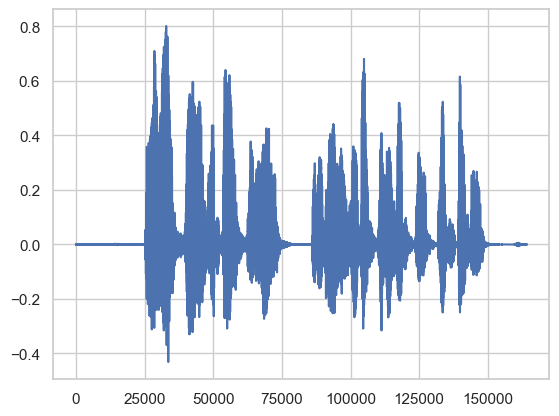

In [166]:
plt.plot(evaluation_dataset[0]['audio']['array'])

In [156]:
# compute number of words per second and add as a new column
df["num_words"] = df['label'].apply(lambda x: len(x.split()))
df['num_letters'] = df['label'].apply(lambda x: len(x.replace(" ", "")))
df["words_per_second"] = df["num_words"] / df['clip_length']
df['letters_per_second'] = df['num_letters'] / df['clip_length']

df.head()

,id,prediction,label,clip_length,CER,WER,model,dataset_name,dataset_subset,dataset_split,prediction_embedding,label_embedding,semantic_distance,num_words,num_letters,words_per_second,letters_per_second
0,rec_90dda503d68dc197f80219a7d3b129a9,derimod udøves retsplanen i det hele i det tid...,derimod udøvedes retsplejen i det hele i det t...,10.26,0.104167,0.266667,whisper-large-v3,coral-v2,read_aloud,test,"[-0.014361421, 0.05218921, -0.018706942, -0.09...","[-0.03685369, 0.03144104, -0.037021983, -0.117...",0.166795,15,82,1.461988,7.992203
1,rec_becc6eb53b441b31116584cd5c4e1c51,bauer klønge støtter kløngeorganisationer til ...,begge klynger støttes af klyngeorganisationer ...,7.32,0.234568,0.727273,whisper-large-v3,coral-v2,read_aloud,test,"[-0.07104228, -0.12548853, -0.06338177, -0.015...","[-0.0125311585, -0.060128797, -0.007917432, -0...",0.517030,11,71,1.502732,9.699454
2,rec_e59f62c2675fea5f9e7e726b51283250,i mildere tilfælde kan asmalt klare sig med pa...,i mildere tilfælde kan smerterne klares med pa...,8.10,0.147059,0.300000,whisper-large-v3,coral-v2,read_aloud,test,"[0.019092456, -0.023992827, -0.031023178, 0.02...","[0.03683996, -0.028660791, 0.04380101, 0.11237...",0.347441,10,59,1.234568,7.283951
3,rec_a47501841f128c1e6eb7fdd21647aa14,grønt er et ørelov liges her gennem og umanget...,grant at ødelægge lees hær gennem udmattelse v...,9.96,0.376344,0.857143,whisper-large-v3,coral-v2,read_aloud,test,"[0.028158227, -0.008324441, 0.06434102, -0.056...","[-0.04051919, 0.16661945, 0.01602321, -0.03350...",0.748699,14,80,1.405622,8.032129
4,rec_9a4da4e1a39901165014ad7354ac8e4f,der er lavet scenarier der forsøger at vise hv...,der er lavet scenarier der søger at vise hvord...,5.82,0.038462,0.071429,whisper-large-v3,coral-v2,read_aloud,test,"[-0.12290491, -0.02050186, 0.007368673, -0.010...","[-0.11009042, -0.02908404, 0.0042077433, -0.00...",0.019895,14,65,2.405498,11.168385


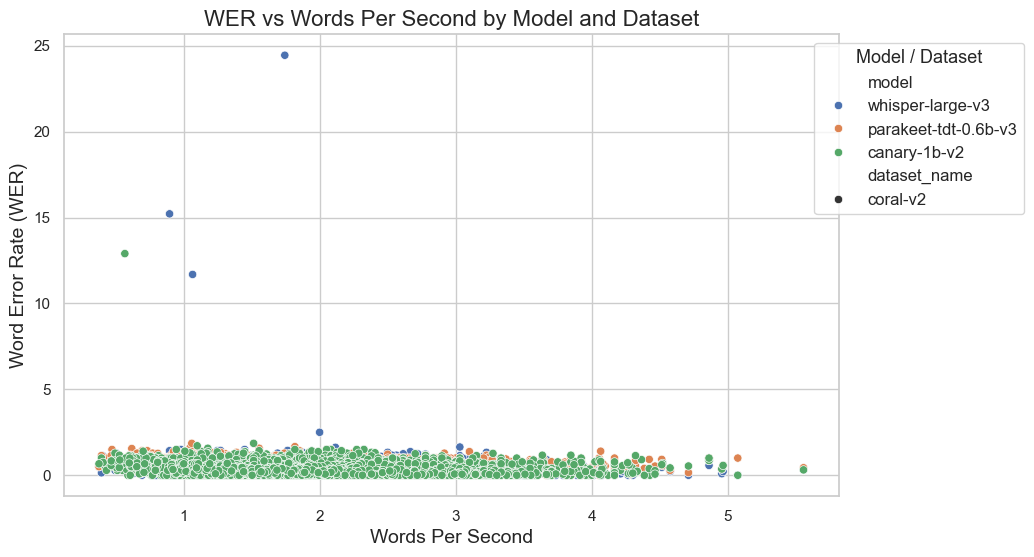

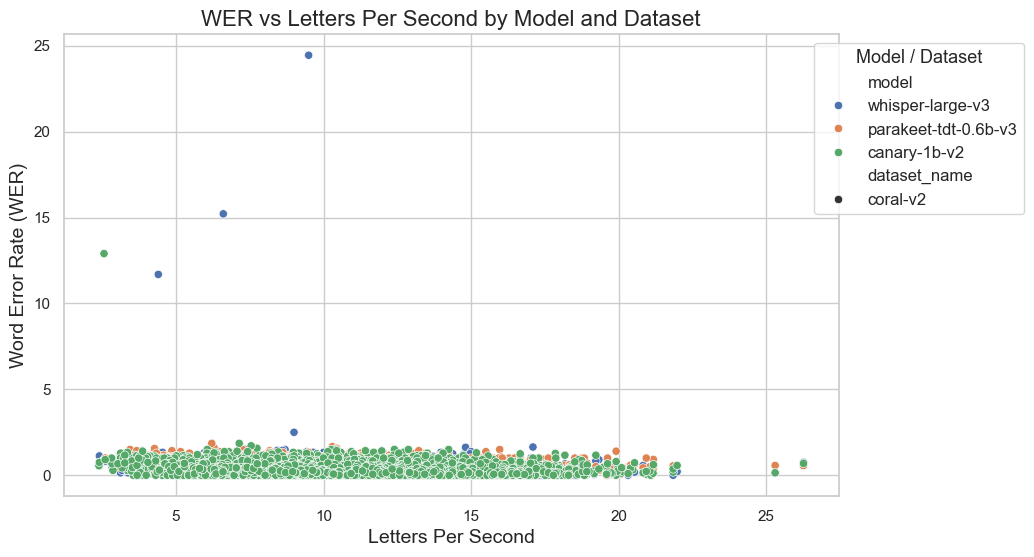

In [160]:
models = df['model'].unique().tolist()
datasets = df['dataset_name'].unique().tolist()

# only include parakeet-tdt-0.6b-v3, canary-1B-v2, and whisper-large-v3
models = [model for model in models if model in ['parakeet-tdt-0.6b-v3', 'canary-1b-v2', 'whisper-large-v3']]
datasets = [dataset for dataset in datasets if dataset in ['coral-v2']]

def plot_wer_vs_words_per_second(
        df: pd.DataFrame,
        models: Optional[List[str]] = None,
        datasets: Optional[List[str]] = None):
    
    """Plot WER vs words per second for different models and datasets.
    Args:
        models:
            List of model names to include in the plot. If None, include all models.
        datasets:
            List of dataset names to include in the plot. If None, include all datasets.
    """
    filtered_df = df.copy()
    if models is not None:
        filtered_df = filtered_df[filtered_df['model'].isin(models)]
    if datasets is not None:
        filtered_df = filtered_df[filtered_df['dataset_name'].isin(datasets)]
    # scatterplot of WER vs words per second
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=filtered_df, x='words_per_second', y='WER', hue='model', style='dataset_name')
    plt.title('WER vs Words Per Second by Model and Dataset', fontsize=16)
    plt.xlabel('Words Per Second', fontsize=14)
    plt.ylabel('Word Error Rate (WER)', fontsize=14)
    plt.legend(title='Model / Dataset', fontsize=12, title_fontsize=13, loc='upper right', bbox_to_anchor=(1.25, 1))
    plt.grid(True)
    plt.show()

# scatterplot of WER vs letters per second
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=filtered_df, x='letters_per_second', y='WER', hue='model', style='dataset_name')
    plt.title('WER vs Letters Per Second by Model and Dataset', fontsize=16)
    plt.xlabel('Letters Per Second', fontsize=14)
    plt.ylabel('Word Error Rate (WER)', fontsize=14)
    plt.legend(title='Model / Dataset', fontsize=12, title_fontsize=13, loc='upper right', bbox_to_anchor=(1.25, 1))
    plt.grid(True)
    plt.show()

plot_wer_vs_words_per_second(df, models=models, datasets=datasets)